# 03. Centralized 1D-CNN Baseline Intrusion Detection System

**Research Paper:** *Robust Federated Learning-Based Intrusion Detection for Heterogeneous Vehicular CAN Networks*  
**Model:** Lightweight 1D Convolutional Neural Network (PyTorch)  
**Objective:** Train and thoroughly evaluate the centralized IDS baseline before extending to Federated Learning.

---

### Key Requirements:
1. Load the chronologically split preprocessed CAN windows.
2. Instantiate the lightweight `CAN1DCNN` architecture (~40,000 parameters).
3. Train with reproducible random seeds using cross-entropy and Adam optimizer.
4. Track training and validation loss and F1-score across epochs.
5. Evaluate on the untouched test set (Accuracy, Precision, Recall, F1, FPR, FNR).
6. Profile training time and microsecond-level inference latency.
7. Save model checkpoint, metric results JSON, and visualization figures.


In [1]:
# Environment Setup & Reproducibility
import os
import sys
import time
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

PROJECT_ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.cnn1d import CAN1DCNN, count_parameters
from src.evaluation.metrics import (
    compute_classification_metrics,
    measure_inference_latency,
    plot_training_curves,
    plot_confusion_matrix
)

# Fix random seeds for full scientific reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_MODELS = PROJECT_ROOT / "results" / "models"
RESULTS_METRICS = PROJECT_ROOT / "results" / "metrics"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"

RESULTS_MODELS.mkdir(parents=True, exist_ok=True)
RESULTS_METRICS.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)


Using device: cpu


In [2]:
# 1. Load Processed Dataset
dataset_path = DATA_PROCESSED / "can_ids_processed_dataset.npz"
data = np.load(dataset_path, allow_pickle=True)

X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]

print(f"Loaded dataset from {dataset_path}")
print(f"  Train: X={X_train.shape}, y={y_train.shape} (Attack: {y_train.sum()}, Normal: {len(y_train)-y_train.sum()})")
print(f"  Val:   X={X_val.shape}, y={y_val.shape} (Attack: {y_val.sum()}, Normal: {len(y_val)-y_val.sum()})")
print(f"  Test:  X={X_test.shape}, y={y_test.shape} (Attack: {y_test.sum()}, Normal: {len(y_test)-y_test.sum()})")


Loaded dataset from C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS\data\processed\can_ids_processed_dataset.npz
  Train: X=(21875, 16, 11), y=(21875,) (Attack: 8553, Normal: 13322)
  Val:   X=(4685, 16, 11), y=(4685,) (Attack: 1798, Normal: 2887)
  Test:  X=(4690, 16, 11), y=(4690,) (Attack: 1790, Normal: 2900)


In [3]:
# 2. PyTorch DataLoaders Creation
BATCH_SIZE = 128

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders created with Batch Size = {BATCH_SIZE}")


DataLoaders created with Batch Size = 128


In [4]:
# 3. Model Architecture Instantiation & Parameter Verification (GroupNorm)
model = CAN1DCNN(
    in_channels=11,
    seq_length=16,
    num_classes=2,
    conv_channels=(32, 64, 128),
    fc_hidden=64,
    dropout=0.2,
    num_groups=4
).to(DEVICE)

print("=== 1D-CNN Baseline Architecture (with GroupNorm for FL Readiness) ===")
print(model)

param_counts = count_parameters(model)
print(f"\nParameter Summary:")
print(f"  Trainable Parameters: {param_counts['trainable_parameters']:,}")
print(f"  Total Parameters:     {param_counts['total_parameters']:,}")


=== 1D-CNN Baseline Architecture (with GroupNorm for FL Readiness) ===
CAN1DCNN(
  (conv1): Conv1d(11, 32, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
  (gn1): GroupNorm(4, 32, eps=1e-05, affine=True)
  (conv2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
  (gn2): GroupNorm(4, 64, eps=1e-05, affine=True)
  (conv3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
  (gn3): GroupNorm(4, 128, eps=1e-05, affine=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

Parameter Summary:
  Trainable Parameters: 40,610
  Total Parameters:     40,610


In [5]:
# 4. Training Loop with Epoch Tracking & Best Validation Model Checkpointing
import copy

EPOCHS = 10
LR = 0.001
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history = {
    "train_loss": [],
    "train_f1": [],
    "val_loss": [],
    "val_f1": []
}

best_val_f1 = -1.0
best_epoch = -1
best_model_state = None

print(f"Starting training for {EPOCHS} epochs on {DEVICE}...")
t_start = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    # Train Phase
    model.train()
    running_loss = 0.0
    all_train_preds, all_train_targets = [], []
    
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * len(y_batch)
        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        all_train_preds.extend(preds)
        all_train_targets.extend(y_batch.detach().cpu().numpy())
        
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_f1 = compute_classification_metrics(all_train_targets, all_train_preds)["f1_score"]
    
    # Validation Phase
    model.eval()
    val_running_loss = 0.0
    all_val_preds, all_val_targets = [], []
    
    with torch.no_grad():
        for x_val_b, y_val_b in val_loader:
            x_val_b, y_val_b = x_val_b.to(DEVICE), y_val_b.to(DEVICE)
            val_logits = model(x_val_b)
            v_loss = criterion(val_logits, y_val_b)
            
            val_running_loss += v_loss.item() * len(y_val_b)
            v_preds = torch.argmax(val_logits, dim=1).detach().cpu().numpy()
            all_val_preds.extend(v_preds)
            all_val_targets.extend(y_val_b.detach().cpu().numpy())
            
    epoch_val_loss = val_running_loss / len(val_dataset)
    epoch_val_f1 = compute_classification_metrics(all_val_targets, all_val_preds)["f1_score"]
    
    history["train_loss"].append(epoch_train_loss)
    history["train_f1"].append(epoch_train_f1)
    history["val_loss"].append(epoch_val_loss)
    history["val_f1"].append(epoch_val_f1)
    
    # Track best model checkpoint on validation F1
    if epoch_val_f1 > best_val_f1:
        best_val_f1 = epoch_val_f1
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
    
    print(f"Epoch [{epoch:2d}/{EPOCHS:2d}] | Train Loss: {epoch_train_loss:.4f} - F1: {epoch_train_f1:.4f} | Val Loss: {epoch_val_loss:.4f} - F1: {epoch_val_f1:.4f}")

total_training_time = time.perf_counter() - t_start
print(f"\nTraining complete in {total_training_time:.2f} seconds.")
print(f"Selected Best Checkpoint: Epoch {best_epoch} with Validation F1: {best_val_f1:.4f}")

# Restore best checkpoint for final untouched test set evaluation
model.load_state_dict(best_model_state)


Starting training for 10 epochs on cpu...


Epoch [ 1/10] | Train Loss: 0.1259 - F1: 0.9335 | Val Loss: 0.1046 - F1: 0.9536


Epoch [ 2/10] | Train Loss: 0.0257 - F1: 0.9903 | Val Loss: 0.0383 - F1: 0.9837


Epoch [ 3/10] | Train Loss: 0.0150 - F1: 0.9954 | Val Loss: 0.0204 - F1: 0.9933


Epoch [ 4/10] | Train Loss: 0.0148 - F1: 0.9951 | Val Loss: 0.0169 - F1: 0.9922


...

Epoch [ 7/10] | Train Loss: 0.0132 - F1: 0.9960 | Val Loss: 0.0405 - F1: 0.9830


Epoch [ 8/10] | Train Loss: 0.0067 - F1: 0.9984 | Val Loss: 0.0145 - F1: 0.9942


Epoch [ 9/10] | Train Loss: 0.0066 - F1: 0.9980 | Val Loss: 0.0607 - F1: 0.9769


Epoch [10/10] | Train Loss: 0.0046 - F1: 0.9987 | Val Loss: 0.0543 - F1: 0.9798

Training complete in 27.93 seconds.
Selected Best Checkpoint: Epoch 8 with Validation F1: 0.9942


<All keys matched successfully>

In [6]:
# 5. Untouched Test Set Evaluation (Using Best Checkpoint)
model.eval()
all_test_preds, all_test_targets, all_test_probs = [], [], []

with torch.no_grad():
    for x_test_b, y_test_b in test_loader:
        x_test_b = x_test_b.to(DEVICE)
        logits = model(x_test_b)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        
        all_test_preds.extend(preds)
        all_test_targets.extend(y_test_b.numpy())
        all_test_probs.extend(probs)

test_metrics = compute_classification_metrics(all_test_targets, all_test_preds, all_test_probs)

print("=" * 60)
print("             CENTRALIZED 1D-CNN BASELINE TEST RESULTS")
print("=" * 60)
print(f"Selected Best Epoch:      {best_epoch}")
print(f"Best Validation F1:       {best_val_f1 * 100:.2f}%")
print(f"Test Accuracy:            {test_metrics['accuracy'] * 100:.2f}%")
print(f"Test Precision:           {test_metrics['precision'] * 100:.2f}%")
print(f"Test Recall:              {test_metrics['recall'] * 100:.2f}%")
print(f"Test F1-Score:            {test_metrics['f1_score'] * 100:.2f}%")
print(f"False Positive Rate (FPR): {test_metrics['false_positive_rate'] * 100:.4f}%")
print(f"False Negative Rate (FNR): {test_metrics['false_negative_rate'] * 100:.4f}%")
if test_metrics.get("roc_auc"):
    print(f"Test ROC-AUC:             {test_metrics['roc_auc']:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(all_test_targets, all_test_preds, target_names=["Normal (0)", "Attack (1)"], digits=4))


             CENTRALIZED 1D-CNN BASELINE TEST RESULTS
Selected Best Epoch:      8
Best Validation F1:       99.42%
Test Accuracy:            99.66%
Test Precision:           99.61%
Test Recall:              99.50%
Test F1-Score:            99.55%
False Positive Rate (FPR): 0.2414%
False Negative Rate (FNR): 0.5028%
Test ROC-AUC:             0.9992

Classification Report:
              precision    recall  f1-score   support

  Normal (0)     0.9969    0.9976    0.9972      2900
  Attack (1)     0.9961    0.9950    0.9955      1790

    accuracy                         0.9966      4690
   macro avg     0.9965    0.9963    0.9964      4690
weighted avg     0.9966    0.9966    0.9966      4690



In [7]:
# 6. Latency & Resource Profiling (Single-Sample vs Batched Throughput)
sample_tensor = torch.tensor(X_test[:128], dtype=torch.float32)
latency_stats = measure_inference_latency(model, sample_tensor, num_warmup=30, num_iterations=150, device=DEVICE)

print("=== Edge Latency & Resource Profiling ===")
print(f"Single-Sample Real-Time Latency (batch=1):")
print(f"  Mean:   {latency_stats['single_sample_latency_us']:.2f} microseconds (µs)")
print(f"  Median: {latency_stats['single_sample_median_us']:.2f} microseconds (µs)")
print(f"  p95:    {latency_stats['single_sample_p95_us']:.2f} microseconds (µs)")
print(f"Batched Inference Throughput (batch={latency_stats['batch_size']}):")
print(f"  Batch Latency:            {latency_stats['batch_latency_ms']:.3f} ms ± {latency_stats['std_batch_latency_ms']:.3f} ms")
print(f"  Amortized Per-Sample:     {latency_stats['amortized_batch_latency_us']:.2f} microseconds (µs)")
print(f"  Throughput:               {latency_stats['throughput_samples_sec']:.1f} samples/sec")
print(f"Total Model Parameters:     {param_counts['total_parameters']:,}")
print(f"Training Time (10 epochs):  {total_training_time:.2f} seconds")


=== Edge Latency & Resource Profiling ===
Single-Sample Real-Time Latency (batch=1):
  Mean:   455.99 microseconds (µs)
  Median: 421.05 microseconds (µs)
  p95:    590.59 microseconds (µs)
Batched Inference Throughput (batch=128):
  Batch Latency:            3.462 ms ± 0.313 ms
  Amortized Per-Sample:     27.04 microseconds (µs)
  Throughput:               36975.6 samples/sec
Total Model Parameters:     40,610
Training Time (10 epochs):  27.93 seconds


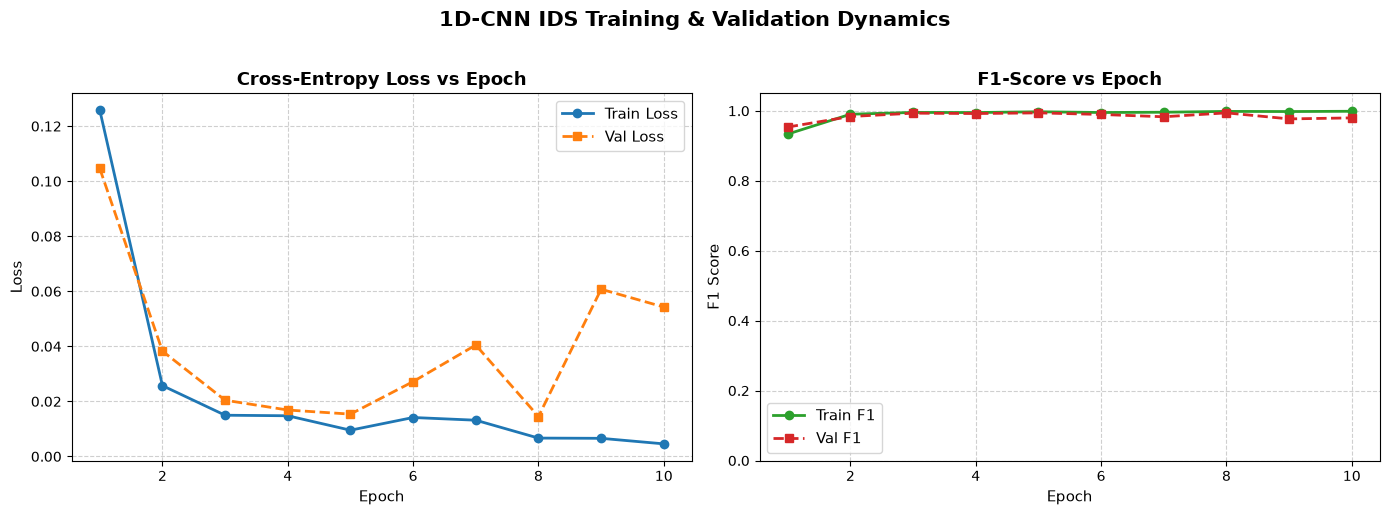

Saved training curves to: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS\results\figures\baseline_training_curves.png


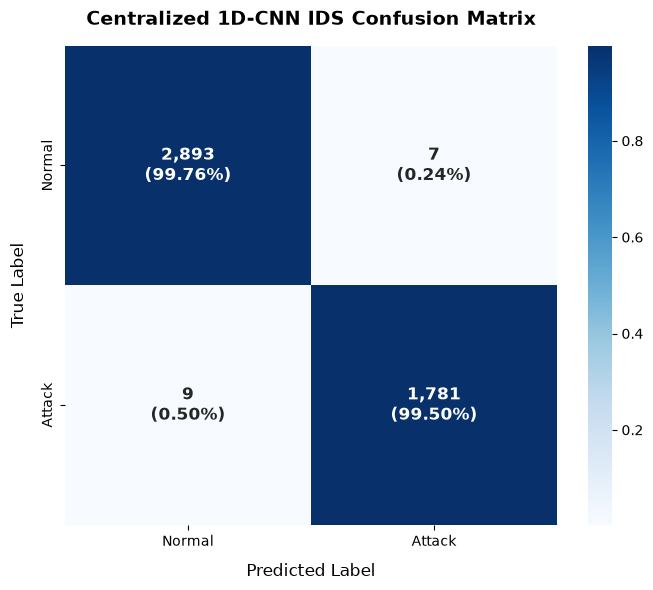

Saved confusion matrix to: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS\results\figures\baseline_confusion_matrix.png


In [8]:
# 7. Visualization: Training Dynamics & Confusion Matrix
curves_fig_path = RESULTS_FIGURES / "baseline_training_curves.png"
plot_training_curves(history, save_path=curves_fig_path)
plt.show()
print(f"Saved training curves to: {curves_fig_path}")

cm_fig_path = RESULTS_FIGURES / "baseline_confusion_matrix.png"
plot_confusion_matrix(test_metrics["confusion_matrix"], class_names=["Normal", "Attack"], save_path=cm_fig_path)
plt.show()
print(f"Saved confusion matrix to: {cm_fig_path}")


In [9]:
# 8. Save Model Checkpoint & Metric Artifacts
checkpoint_path = RESULTS_MODELS / "baseline_1d_cnn.pt"
best_checkpoint_path = RESULTS_MODELS / "centralized_1d_cnn_best.pt"

checkpoint_data = {
    "model_state_dict": best_model_state,
    "model_config": {
        "in_channels": 11,
        "seq_length": 16,
        "num_classes": 2,
        "conv_channels": (32, 64, 128),
        "fc_hidden": 64,
        "norm_type": "GroupNorm",
        "num_groups": 4,
        "dropout": 0.2
    },
    "history": history,
    "best_epoch": best_epoch,
    "best_validation_f1": best_val_f1,
    "training_seed": SEED,
    "learning_rate": LR,
    "weight_decay": WEIGHT_DECAY,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "metrics": test_metrics
}

torch.save(checkpoint_data, checkpoint_path)
torch.save(checkpoint_data, best_checkpoint_path)
print(f"Saved model checkpoint:      {checkpoint_path}")
print(f"Saved best model checkpoint: {best_checkpoint_path}")

# Save JSON results
results_dict = {
    "model": "1D-CNN Baseline (GroupNorm)",
    "architecture": "CAN1DCNN",
    "normalization": "GroupNorm (G=4)",
    "parameters": param_counts,
    "best_epoch": best_epoch,
    "best_validation_f1": round(best_val_f1, 6),
    "latency": latency_stats,
    "training_time_seconds": round(total_training_time, 2),
    "test_metrics": test_metrics,
    "reproducibility": {
        "seed": SEED,
        "device": str(DEVICE),
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR,
        "weight_decay": WEIGHT_DECAY
    }
}

metrics_json_path = RESULTS_METRICS / "baseline_results.json"
metrics_v2_path = RESULTS_METRICS / "centralized_baseline_v2.json"

with open(metrics_json_path, "w", encoding="utf-8") as f:
    json.dump(results_dict, f, indent=2)
with open(metrics_v2_path, "w", encoding="utf-8") as f:
    json.dump(results_dict, f, indent=2)

print(f"Saved metrics JSON: {metrics_json_path}")
print(f"Saved metrics JSON: {metrics_v2_path}")


Saved model checkpoint:      C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS\results\models\baseline_1d_cnn.pt
Saved best model checkpoint: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS\results\models\centralized_1d_cnn_best.pt
Saved metrics JSON: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS\results\metrics\baseline_results.json
Saved metrics JSON: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS\results\metrics\centralized_baseline_v2.json
